# Probabilidad de completar el album con tres cajas

Parametros reales del album:

- Estampas del album: `N = 980`.
- Estampas por sobre: `S = 7`.
- Sobres por caja: `104`.
- Tres cajas: `M = 312` sobres.
- Simulaciones: `R = 15000`.
- Semilla: `2026`.
- Precio por caja: `Q975.00`.

Se calcula la probabilidad sin intercambio y, como referencia adicional, con intercambio `K=4`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEMILLA = 2026
N = 980
S = 7
R = 15_000

SOBRES_POR_CAJA = 104
CAJAS = 3
M = CAJAS * SOBRES_POR_CAJA

PRECIO_CAJA = 975.00
costo_total = CAJAS * PRECIO_CAJA


## Funcion de simulacion

Para reducir la carga, la simulacion guarda cuantas estampas distintas tiene el album. Si hay `c` estampas coleccionadas, el numero de estampas nuevas en el siguiente sobre sigue una distribucion hipergeometrica. Despues de cada sobre se aplican todos los canjes posibles de repetidas por estampas faltantes.

Cuando `k=None`, el escenario es sin intercambio. Cuando `k=4`, cada 4 repetidas acumuladas producen una estampa faltante.


In [2]:
def simular_probabilidad_completar(n, s, r, m, k=None, semilla=2026):
    rng = np.random.default_rng(semilla)
    coleccionadas = np.zeros(r, dtype=np.int16)
    repetidas = np.zeros(r, dtype=np.int16)

    for _ in range(m):
        activos = coleccionadas < n
        idx = np.flatnonzero(activos)
        if idx.size == 0:
            break

        nuevas = rng.hypergeometric(n - coleccionadas[idx], coleccionadas[idx], s)
        duplicadas = s - nuevas
        coleccionadas[idx] += nuevas.astype(np.int16)

        if k is not None:
            repetidas[idx] += duplicadas.astype(np.int16)
            canjes = np.minimum(repetidas[idx] // k, n - coleccionadas[idx])
            coleccionadas[idx] += canjes.astype(np.int16)
            repetidas[idx] -= (canjes * k).astype(np.int16)

    completado = coleccionadas >= n
    return {
        "probabilidad": completado.mean(),
        "exitos": int(completado.sum()),
        "coleccionadas": coleccionadas,
        "faltantes": n - coleccionadas,
    }


In [3]:
resultados = {
    "Sin intercambio": simular_probabilidad_completar(N, S, R, M, k=None, semilla=SEMILLA),
    "Intercambio K=4": simular_probabilidad_completar(N, S, R, M, k=4, semilla=SEMILLA),
}

print(f"Sobres comprados: {M}")
print(f"Costo total: Q{costo_total:,.2f}")
print()
for etiqueta, resultado in resultados.items():
    print(etiqueta)
    print(f"  Exitos: {resultado['exitos']} de {R}")
    print(f"  Probabilidad estimada: {resultado['probabilidad']:.4f}")
    print(f"  Faltantes promedio: {resultado['faltantes'].mean():.4f}")
    print(f"  Faltantes mediana: {np.median(resultado['faltantes']):.0f}")
    print(f"  Minimo de estampas coleccionadas: {resultado['coleccionadas'].min()}")


Sobres comprados: 312
Costo total: Q2,925.00

Sin intercambio
  Exitos: 0 de 15000
  Probabilidad estimada: 0.0000
  Faltantes promedio: 104.6947
  Faltantes mediana: 105
  Minimo de estampas coleccionadas: 837
Intercambio K=4
  Exitos: 15000 de 15000
  Probabilidad estimada: 1.0000
  Faltantes promedio: 0.0000
  Faltantes mediana: 0
  Minimo de estampas coleccionadas: 980


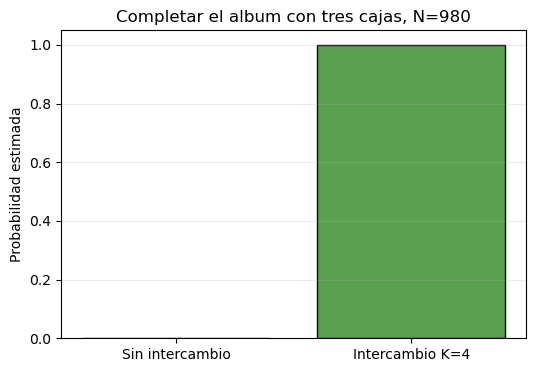

In [12]:
etiquetas = list(resultados.keys())
probabilidades = [resultados[e]["probabilidad"] for e in etiquetas]

plt.figure(figsize=(6, 4))
plt.bar(etiquetas, probabilidades, color=["#4C78A8", "#59A14F"], edgecolor="black")
plt.ylim(0, 1.05)
plt.ylabel("Probabilidad estimada")
plt.title("Completar el album con tres cajas, N=980")
plt.grid(axis="y", alpha=0.25)
plt.show()


## Respuesta

Con tres cajas (`312` sobres), la probabilidad estimada de completar el album sin intercambio fue `0.0000`, con `0` exitos en `15000` simulaciones. En promedio faltaron `104.6947` estampas.

Con intercambio `K=4`, la probabilidad estimada fue `1.0000`, con `15000` exitos en `15000` simulaciones.

El costo de tres cajas es `3 x Q975.00 = Q2925.00`.

Nota: los valores `0.0000` y `1.0000` significan que no se observaron exitos o fallos, respectivamente, en estas `15000` simulaciones; no son pruebas matematicas absolutas.


## Revisión de consistencia

El resultado `1.0000` con tres cajas sí es llamativo, pero tiene sentido con `K=4`. Si se abrieran todos los sobres primero y se hicieran los canjes al final, con `T = M × S` estampas compradas y `U` estampas distintas naturales, el máximo aproximado alcanzable sería:

`U + floor((T - U)/4)`.

Para completar se necesita `U >= ceil((4×980 - T)/3)`. Con tres cajas, `T = 312×7 = 2184`, por lo que el umbral baja a solo `579` estampas distintas naturales. En una revisión con `15000` pruebas, sin canje se obtuvieron entre `837` y `907` estampas distintas naturales, siempre muy por encima de `579`.

Por eso con intercambio `K=4` se completó el álbum en las `15000` pruebas. No es que tres cajas sin intercambio alcancen; sin intercambio todavía faltan unas `105` estampas en promedio. El cambio fuerte viene de que las tres cajas generan suficientes repetidas para canjear casi todas las faltantes.
